# KNN Classification Project

This project applies the K-Nearest Neighbors algorithm to a labeled dataset to predict class membership. It includes data preprocessing, visualization, model building, and performance tuning using the elbow method.

## 📌 Overview

- **Goal**: Predict a target class using KNN based on feature similarity
- **Techniques Used**:
  - Exploratory Data Analysis (EDA) with pair plots
  - Data standardization with `StandardScaler`
  - Model evaluation with confusion matrix and classification report
  - Hyperparameter tuning with the elbow method to choose optimal `K`

## 🔧 Tools & Libraries

- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- scikit-learn

## 📊 Steps Performed

1. **Data Loading & Visualization**  
   - Loaded dataset from CSV  
   - Explored feature distributions by class using seaborn pair plots

2. **Preprocessing**  
   - Standardized features (important for KNN performance)

3. **Model Training & Evaluation**  
   - Built and trained a KNN classifier with initial `K=1`  
   - Evaluated using confusion matrix and classification report

4. **Model Tuning**  
   - Identified optimal K by plotting error rate vs. `K`  
   - Retrained model with chosen value (`K=30`) for improved results

## ▶️ To Run the Code

1. Install required libraries:
   ```bash
   pip install pandas numpy matplotlib seaborn scikit-learn
   ```

2. Run the Python script or Jupyter Notebook

## 📈 Result

After tuning, the final model was evaluated and showed improved classification performance on the test set.


In [1]:
# Imports 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
# EDA
df = pd.read_csv('KNN-Project-Data.csv')
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


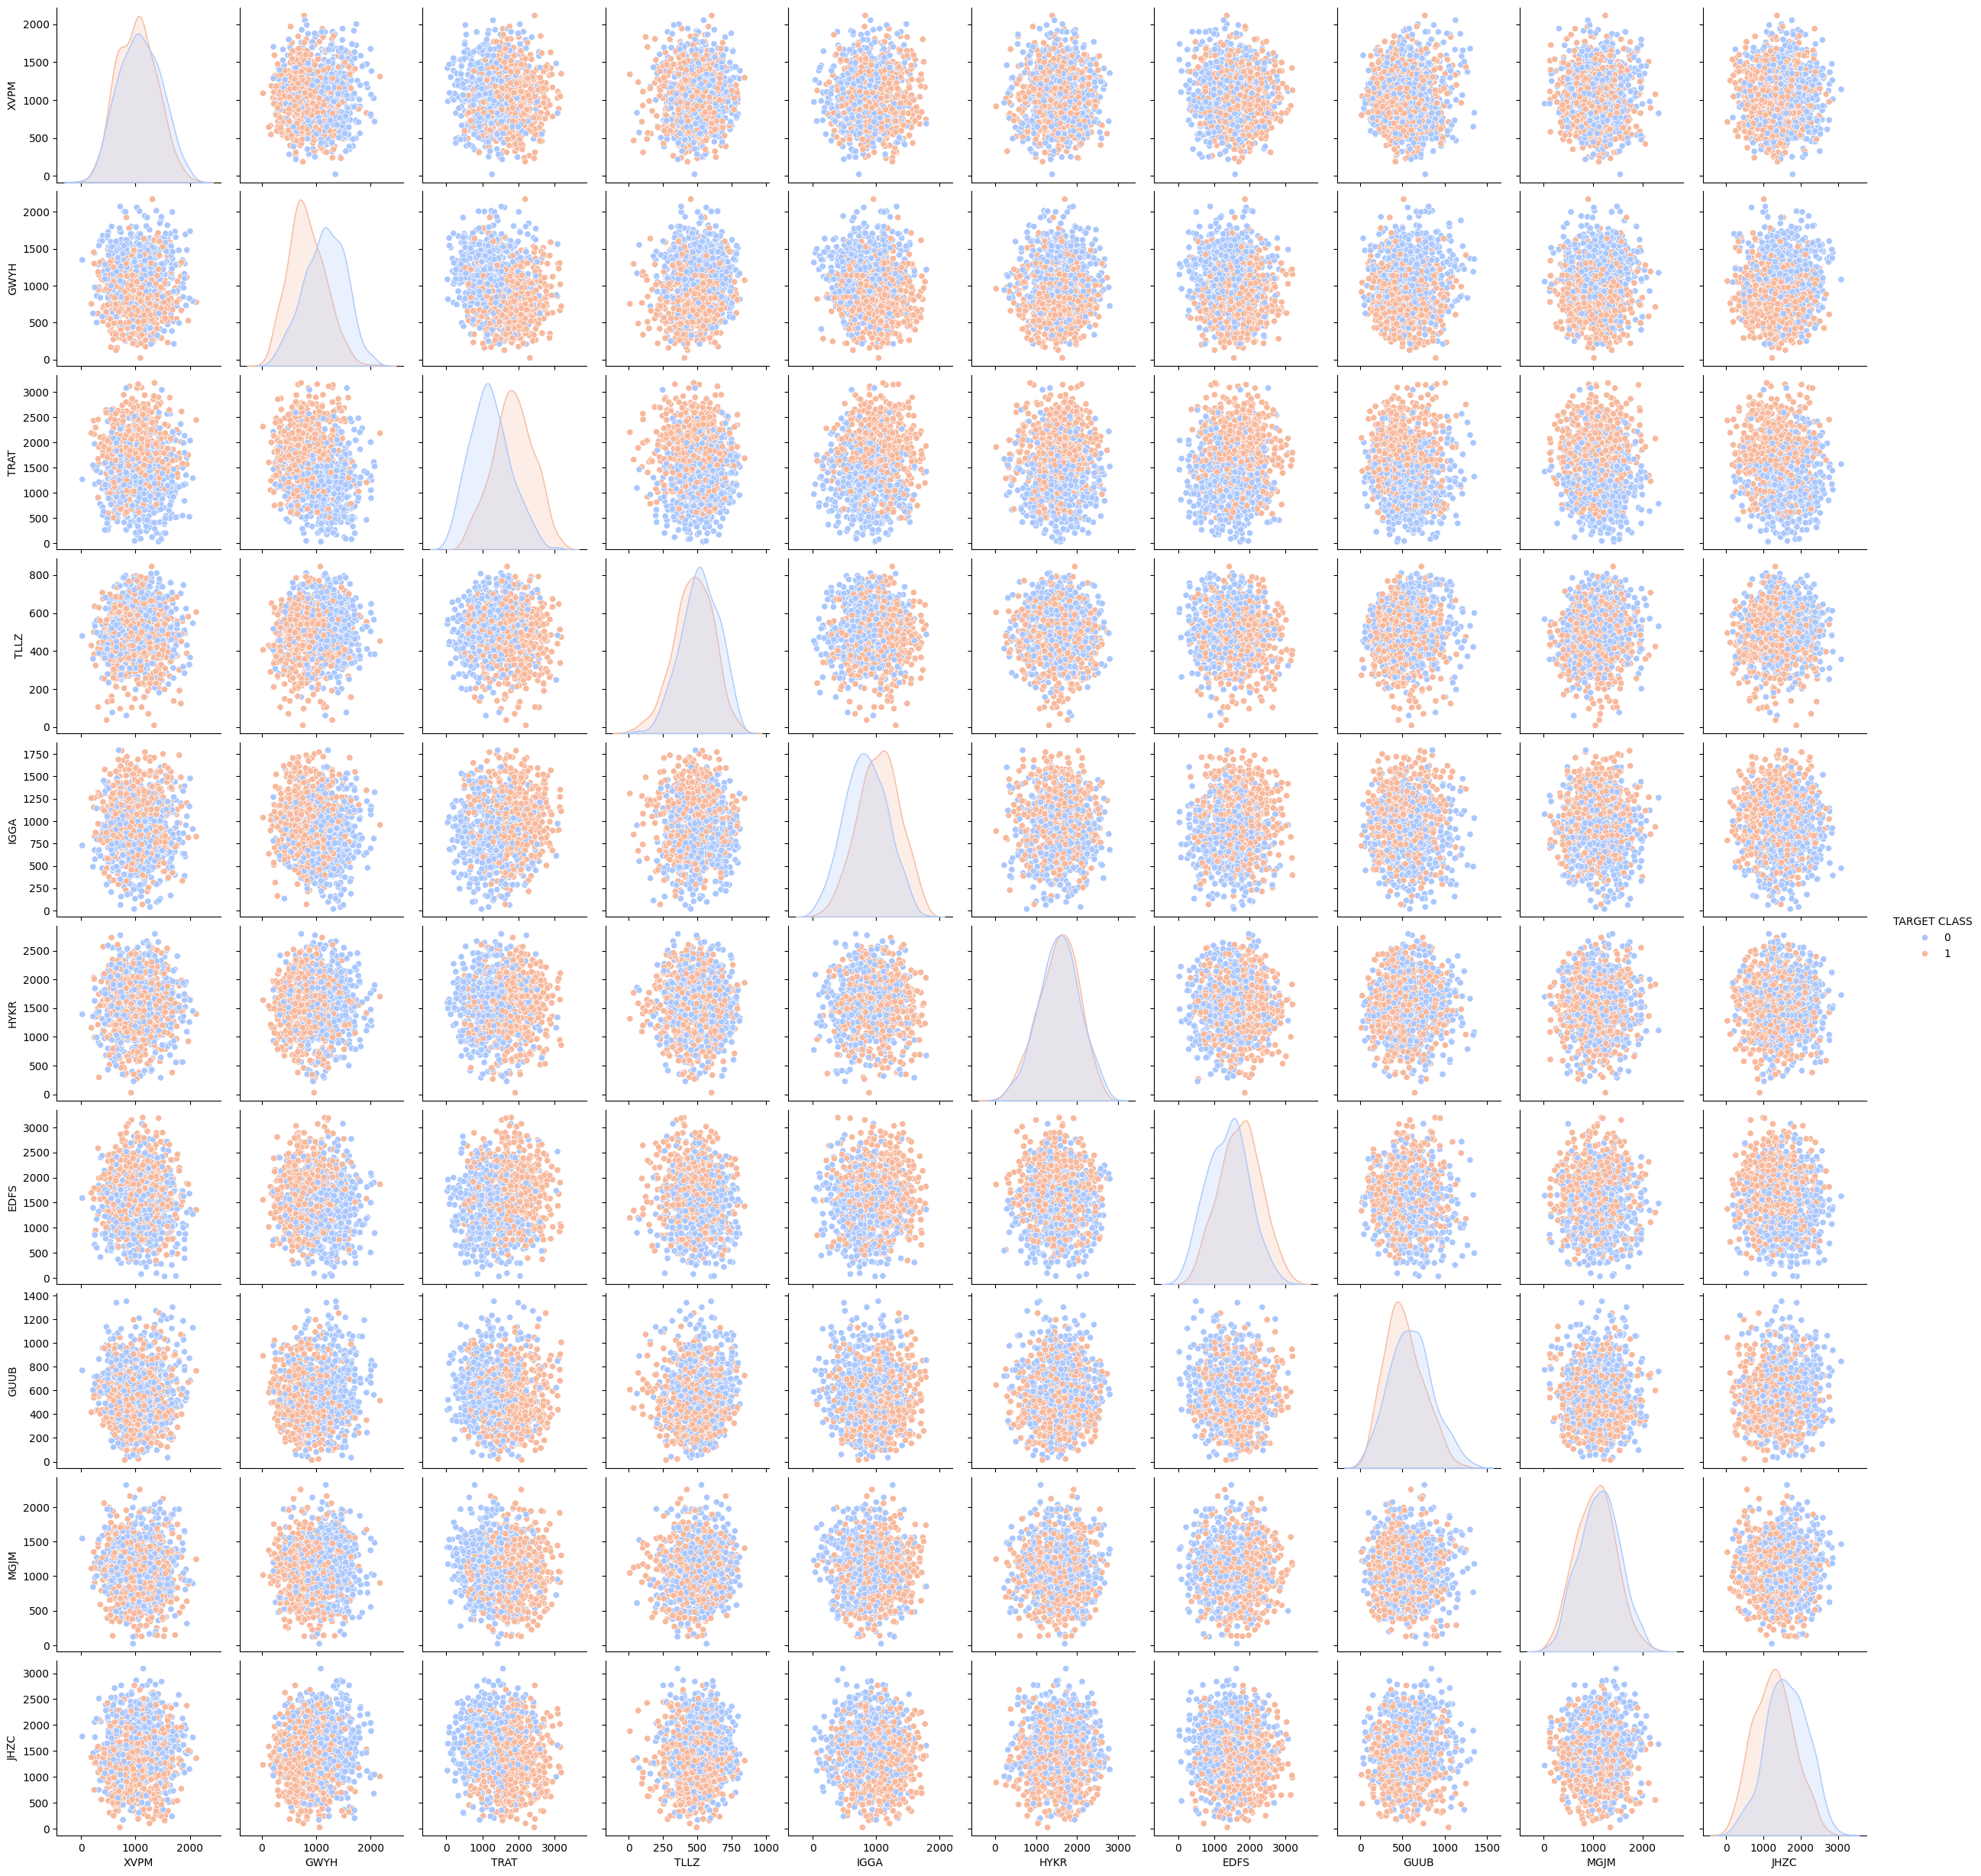

In [3]:
sns.pairplot(df, hue='TARGET CLASS', palette='coolwarm')

In [4]:
# Stadardize the variables
from sklearn.preprocessing import StandardScaler

In [5]:
# create object of standard scalar
scalar = StandardScaler()

In [6]:
# Fit scalar to the features 
scalar.fit(df.drop('TARGET CLASS', axis = 1))

StandardScaler()

In [7]:
# Transform features to scaled version 
scaled_features = scalar.transform(df.drop('TARGET CLASS', axis=1))

In [8]:
df_feat = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df.head(3)

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1


In [9]:
# Train test split 
from sklearn.model_selection import train_test_split

In [10]:
X = df_feat
y = df['TARGET CLASS']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=101)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
# create knn model instance with n_neighbors = 1
knn = KNeighborsClassifier(n_neighbors=1)

In [13]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [14]:
# pred 
pred = knn.predict(X_test)

In [15]:
# Evaluations
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.73      0.72      0.72       152
           1       0.71      0.72      0.72       148

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300



In [17]:
print(confusion_matrix(y_test, pred))

[[109  43]
 [ 41 107]]


In [18]:
# choose better k value with elbow method & retrain model with new k value
error_rate = []
    
for i in range (1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))    


Text(0, 0.5, 'Error Rate')

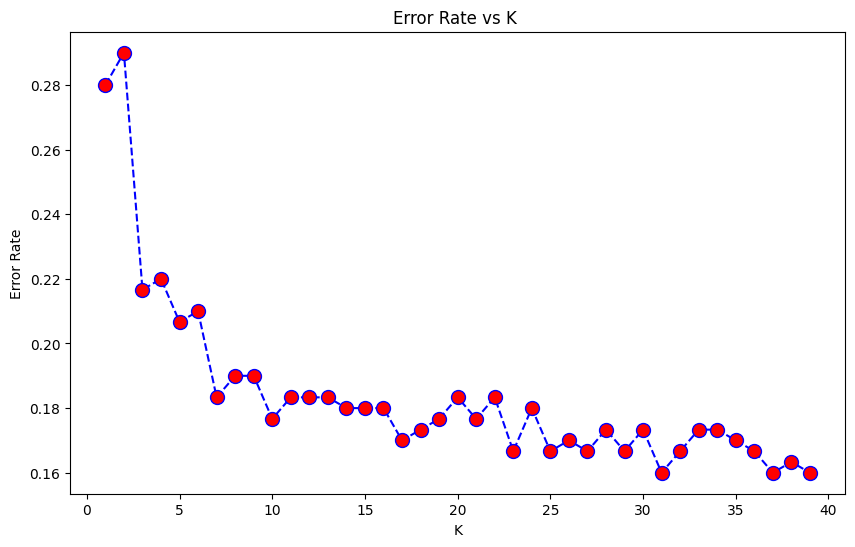

In [19]:
# Evaluate
plt.figure(figsize=(10,6 ))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='--', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs K ')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [20]:
# Retrain with new k value 
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

print(classification_report(y_test, pred))
print('\n')
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       152
           1       0.82      0.84      0.83       148

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300



[[124  28]
 [ 24 124]]
